# Display a full DECam focal-plane calibration image

Uses `lsst.daf.butler` to pull a combined calibration product (one image per detector) out of the `desgw_postgres` repo, then mosaics all 62 CCDs into a single focal-plane view with `lsst.afw.cameraGeom.utils.showCamera`.

In [1]:
repo = "/global/cfs/cdirs/lsst/production/gen3/rubin/decam/repo"
collections = ["DECam/calib/desgw_pilot/flat", "DECam/calib/desgw_pilot/bias", "DECam/calib/desgw_pilot/fringe"]

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
DATA_DIR = "../figures"
from lsst.daf.butler import Butler
import lsst.afw.display as afwDisplay
import lsst.afw.cameraGeom.utils as cgu

## Pick the calibration type and collection

- `bias` and `crosstalk` are keyed only by `{instrument, detector}` — one combined image per CCD, no filter dependence.
- `flat` and `fringe` are also keyed by `band`/`physical_filter`, so a `band` must be chosen below when using those.

Defaults to `bias` since it needs no extra selection to get one image per detector across the whole focal plane.

In [29]:
calibType = "fringe"  # one of: "bias", "flat", "fringe"
band = "z"  # only used when calibType is "flat" or "fringe"
calibTag = "2014"

calibCollection = f"u/seanmacb/DECam/calib/ELAIS_pilot/{calibType}/{calibTag}"
if calibType =='flat':
    calibCollection+=f"/{band}_band"

band_filt = {"g": "g DECam SDSS c0001 4720.0 1520.0",
"r": "r DECam SDSS c0002 6415.0 1480.0",
"i": "i DECam SDSS c0003 7835.0 1470.0",
"z": "z DECam SDSS c0004 9260.0 1520.0"}
getKwargs = {"instrument": "DECam"}
if calibType in ("flat", "fringe"):
    getKwargs["band"] = band
    getKwargs['physical_filter'] = band_filt[band]
print(calibCollection)

u/seanmacb/DECam/calib/ELAIS_pilot/fringe/2014


In [30]:
# "DECam/calib/unbounded" holds the camera geometry dataset used to lay out the mosaic
butler = Butler(repo, collections=[calibCollection, "DECam/calib/curated/unbounded"])

camera = butler.get("camera", instrument="DECam")
print(f"{camera.getName()}: {len(camera)} detectors")

DECam: 62 detectors


## Build the focal-plane mosaic

`ButlerImage` fetches each detector's image for the chosen `calibType` on demand; `showCamera` tiles them into one focal-plane display. `binSize` controls how much each CCD is downsampled — larger is faster (all 62 detectors at `binSize=16` takes roughly a minute).

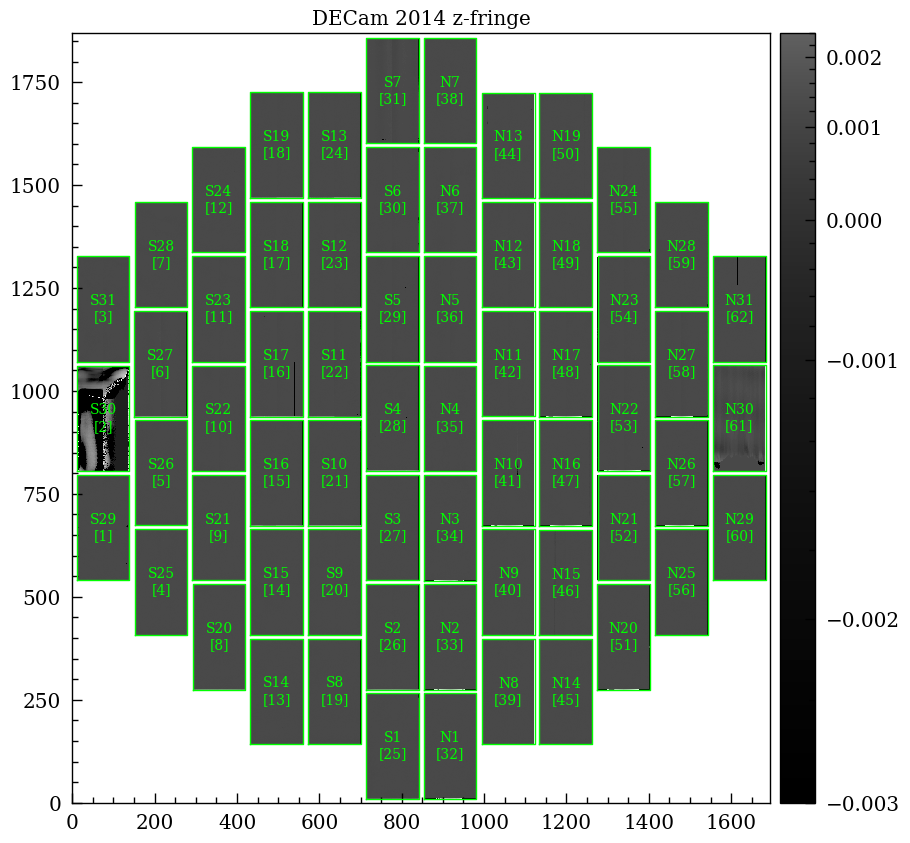

In [31]:
afwDisplay.setDefaultBackend("matplotlib")
fig = plt.figure(figsize=(10, 10))
disp = afwDisplay.Display(frame=fig)
disp.scale(
    "asinh",'zscale' # For the biases + fringes
           # 'linear', min=0.7,max=1.3 # For the flats
          )

imageSource = cgu.ButlerImage(butler, calibType, **getKwargs)

mosaic = cgu.showCamera(
    camera,
    imageSource=imageSource,
    binSize=16,
    display=disp,
    title=f"DECam {calibTag} {band+'-' if calibType!='bias' else ""}{calibType}",
)
fig.savefig(os.path.join(DATA_DIR,f"{calibTag} {calibType}{"-"+band if calibType!='bias' else ""}.jpg"),dpi=300)